# ⚡ **RNN**



https://www.youtube.com/watch?v=3OljkWQ2Uc0

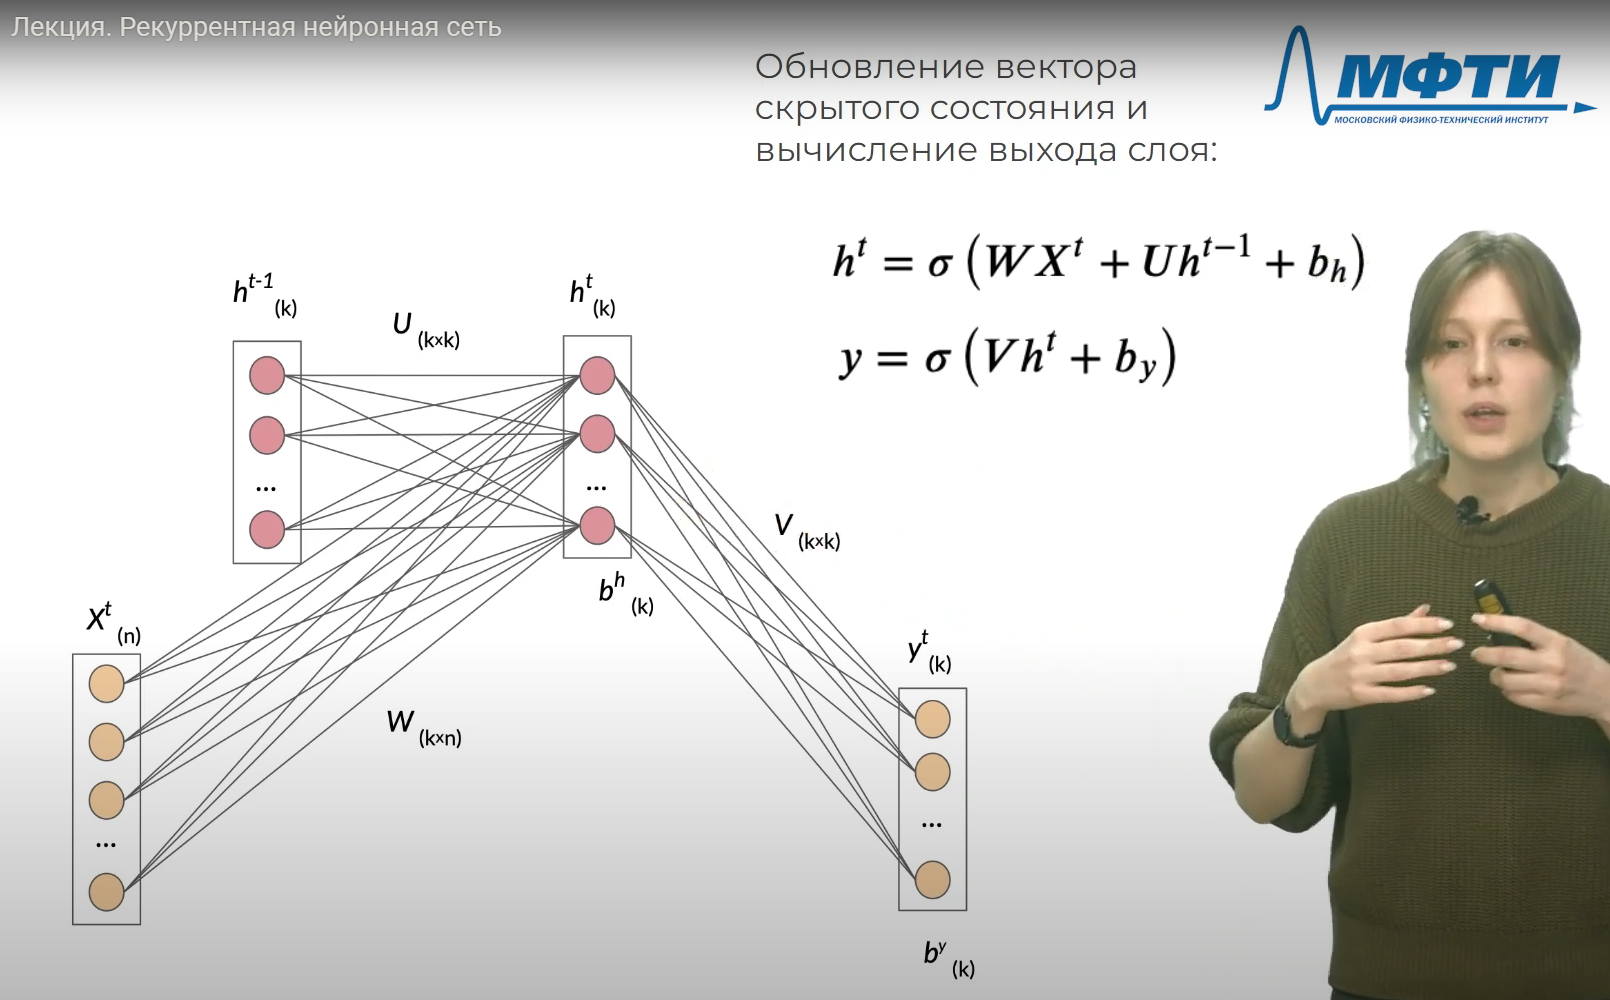

# **1. Vanilla RNN**

In [451]:
import numpy as np
from scipy.special import expit as sigmoid

# Размерности данных
n = 3  # размер входного вектора
k = 3  # размер скрытого состояния

W = np.array([[0.1, 0.2, 0.3], [0.2, 0.3, 0.4], [0.3, 0.4, 0.5]]) # Веса для входа
U = np.array([[0.1, 0.2, 0.3], [0.2, 0.3, 0.4], [0.3, 0.4, 0.5]]) # Веса для скрытого состояния
V = np.array([[0.1, 0.2, 0.3], [0.2, 0.3, 0.4], [0.3, 0.4, 0.5]]) # Веса для выхода
prev_h = np.array([[0], [0], [0]]) # Предыдущее скрытое состояние
bh = np.array([[0.1], [0.2], [0.3]]) # смещения
by = np.array([[0.3], [0.2], [0.1]]) # смещения
x = np.array([[1], [2], [3]]) # Входные данные (первый шаг времени)

## Code 1

In [452]:
# Code #1
# print(h.T, y.T)
# [[0.81757448 0.90024951 0.94784644]] [[0.69976126 0.73355375 0.76482108]]

h = sigmoid(W@x + U@prev_h + bh)
y = sigmoid(V@h + by)
print(h.T, y.T)

[[0.81757448 0.90024951 0.94784644]] [[0.69976126 0.73355375 0.76482108]]


## Code 2

In [453]:
# Что будет в следующий момент времени, если подать на вход х2?
x2 = np.array([[0.2], [0.2], [0.2]]) # Входные данные (второй шаг времени)
# Code #2
h = sigmoid(W@x2 + U@h + bh)
y = sigmoid(V@h + by)
print(h.T, y.T)
# [[0.68268992 0.76722867 0.83469793]] [[0.6839802  0.71106986 0.73673117]]

[[0.68268992 0.76722867 0.83469793]] [[0.6839802  0.71106986 0.73673117]]


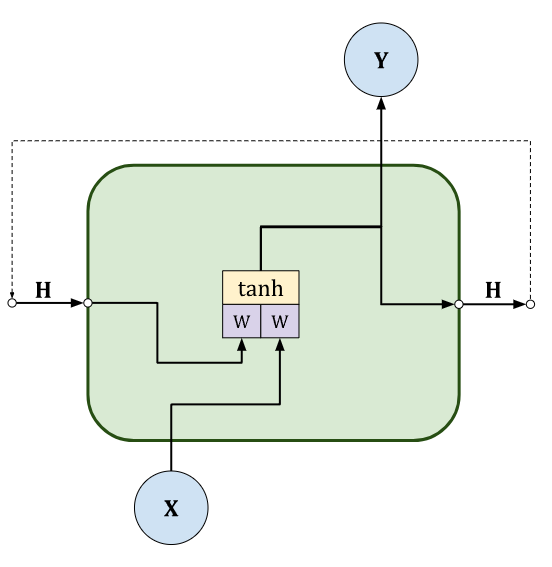

\begin{align*}
h^{i} &= \tanh(W X^{i} + U h^{i-1} + b_{h}) \\
y^{i} &= \sigma(W_{y} h^{i} + b_{y}^{i})
\end{align*}

Это формулы, описывающие шаг рекуррентной нейронной сети (RNN), где:
- $ h^{i} $ - скрытое состояние на шаге $ i $
- $ X^{i} $ - вход на шаге $ i $
- $ y^{i} $ - выход на шаге $ i $
- $ W, U, W_y $ - матрицы весов
- $ b_h, b_y $ - векторы смещений
- $ \tanh $ и $ \sigma $ - функции активации

## Code 3

In [454]:
# Замените функцию активации для внутреннего состояния на tanh, если подать на вход х3?
x3 = np.array([[0.3], [0.3], [0.3]]) # Входные данные (третий шаг времени)
from numpy import tanh
# Code #3
h = tanh(W@x3 + U@h + bh)
y = sigmoid(V@h + by)
print(h.T, y.T)
# [[0.59934483 0.79341621 0.89939558]] [[0.6874955  0.71456346 0.74017296]]

[[0.63641445 0.82445986 0.92000315]] [[0.69094359 0.71962901 0.74662829]]


# **2. Sequence to sequence**

Эта конфигурация применяется, когда мы хотим при помощи сети преобразовать последовательность в последовательность. Обычно это генеративная модель, например, для текстов, на каждом шаге в этом случае сеть выдаёт новую букву (вернее вектор вероятностей для букв алфавита).

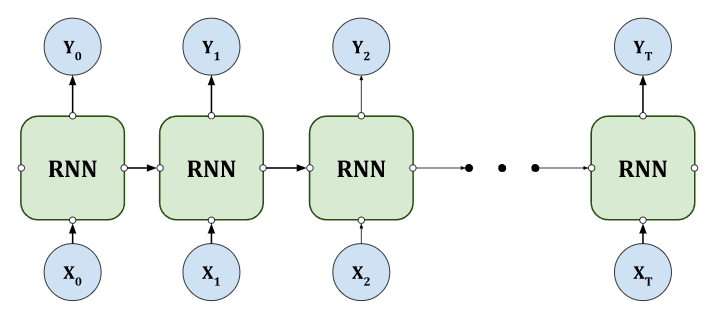

In [455]:
import numpy as np
from scipy.special import expit as sigmoid

np.random.seed(0)

# Размерности данных
input_size  = 3 # размер входного вектора
hidden_size = 3 # размер скрытого состояния
output_size = 3 # размер выходного вектора

# Случайные веса
W  = np.random.randn(hidden_size, input_size)  # Веса для входа
U  = np.random.randn(hidden_size, hidden_size)  # Веса для скрытого состояния
bh = np.random.randn(hidden_size, 1)  # Смещение скрытого слоя
# Веса для выхода (добавим их, так как они не были указаны ранее)
V  = np.random.randn(output_size, hidden_size) # Веса для выхода
by = np.random.randn(output_size, 1) # Смещение выхода

# Входные данные
x0 = np.array([[1], [2], [3]])
x1 = np.array([[2], [3], [4]])
x2 = np.array([[3], [4], [5]])

# Предыдущее скрытое состояние (инициализируется нулями)
init_h = np.zeros((hidden_size, 1))

# Прямой проход через RNN ячейку
def rnn_cell(x, prev_h):
    # Вычисляем новое скрытое состояние
    h = np.tanh(W@x + U@prev_h + bh)
    y = sigmoid(V@h + by)
    return h, y

# Вычисляем новое скрытое состояние
h, y0 = rnn_cell(x0, init_h)

print("Новое скрытое состояние:")
print(h)

Новое скрытое состояние:
[[ 0.99998216]
 [ 0.97526307]
 [-0.97646426]]


## Code 4

In [456]:
# Получите y0, y1, y2 при входных x0, x1, x2
# Результаты должны быть:
h, y1 = rnn_cell(x1, h)
h, y2 = rnn_cell(x2, h)
print(y0.T, y1.T, y2.T)
# y0.T = [[0.91500248 0.76581083 0.26602599]]
# y1.T = [[0.79363136 0.77094962 0.75087103]]
# y2.T = [[0.75705709 0.77322695 0.82050451]]

[[0.91500248 0.76581083 0.26602599]] [[0.79363136 0.77094962 0.75087103]] [[0.75705709 0.77322695 0.82050451]]


Ещё один вариант, когда сеть преобразует последовательность в последовательность, может быть вот таким:

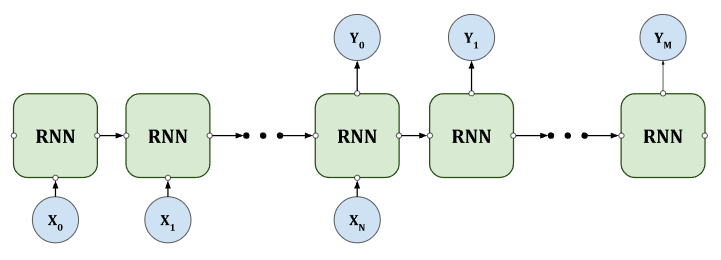

На самом деле это сильно похоже на вариант encoder-decoder, когда входная последовательность кодируется (закодированые данные оказываются во внутреннем состоянии сети), а затем декодируется. Например, такая схема используется для переводов текстов или для работы с видео.

## Code 5

- Начальные входное векторы подаются один раз один за одним.
$ h^{i} = \tanh(W X^{i} + U h^{i-1} + b_{h}) $
- На последующих шагах входной вектор отсутствует (используются нули).
$ h^{i} = \tanh(U h^{i-1} + b_{h}) $
- Сеть генерирует выходы только на основе скрытого состояния и своих внутренних параметров.

In [457]:
# Получите y0, y1, y2 при входных x0, x1, x2
# Результаты должны быть:
dummy_x = np.zeros((hidden_size, 1))
h, _ = rnn_cell(x0, init_h)
h, _ = rnn_cell(x1, h)
h, y0 = rnn_cell(x2, h)
h, y1 = rnn_cell(dummy_x, h)
h, y2 = rnn_cell(dummy_x, h)
print(y0.T, y1.T, y2.T)
# y0.T = [[0.75705709 0.77322695 0.82050451]]
# y1.T = [[0.83106236 0.88406874 0.1700226 ]]
# y2.T = [[0.5843765  0.57208067 0.05908403]]

[[0.75705709 0.77322695 0.82050451]] [[0.83106236 0.88406874 0.1700226 ]] [[0.5843765  0.57208067 0.05908403]]


# **3. Sequence to one**

Эта конфигурация применима для решения задач классификации, например, текстов или видео, когда последовательность слов (или изображений) подаются на вход сети, а в качестве выхода получаем один вектор вероятностей для классов.

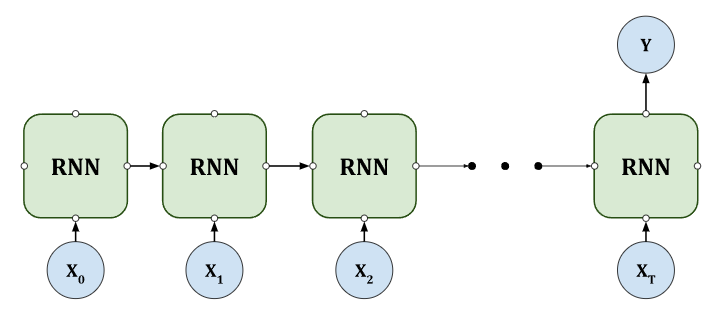

# **4. One to sequence**

Ситуация обратная предыдущей, на вход приходит один элемент, а на выходе получаем целую последовательность. Например, таким образом можно генерировать текстовые подписи к изображению подаваемому на вход.

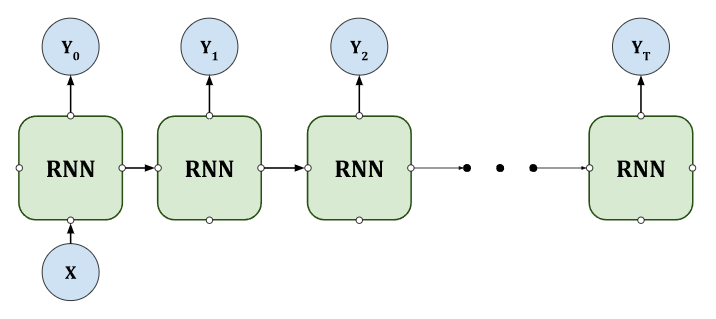

# **5. Backpropagation throught time**

In [458]:
import numpy as np
from scipy.special import expit as sigmoid

np.random.seed(0)

# Размерности данных
input_size = 3  # размер входного вектора
hidden_size = 3  # размер скрытого состояния
output_size = 3  # размер выходного вектора

# Случайные веса
W = np.random.randn(hidden_size, input_size)  # Веса для входа
U = np.random.randn(hidden_size, hidden_size)  # Веса для скрытого состояния
bh = np.random.randn(hidden_size, 1)  # Смещение скрытого слоя
V = np.random.randn(output_size, hidden_size)  # Веса для выхода
by = np.random.randn(output_size, 1)  # Смещение выхода

# Пример входных данных (последовательность из 3 шагов)
x0 = np.array([[1], [2], [3]])
x1 = np.array([[2], [3], [4]])
x2 = np.array([[3], [4], [5]])
x_seq = [x0, x1, x2]  # Последовательность входов

# Пример целевых значений (ожидаемые выходы для каждого шага)
y0 = np.array([[0.1], [0.2], [0.3]])
y1 = np.array([[0.2], [0.3], [0.4]])
y2 = np.array([[0.3], [0.4], [0.5]])
y_seq = [y0, y1, y2]  # Последовательность целевых значений

# Гиперпараметры обучения
learning_rate = 0.01
epochs = 100

# Прямой проход через RNN ячейку
def rnn_cell(x, prev_h):
    """Одна ячейка RNN"""
    h = np.tanh(np.dot(W, x) + np.dot(U, prev_h) + bh)
    return h

# Прямой проход через выходной слой
def output_layer(h):
    """Вычисление выхода сети"""
    y = np.dot(V, h) + by
    return y

# Прямой проход через всю последовательность
def forward(x_seq, prev_h):
    """Прямой проход через всю последовательность"""
    h_seq = [prev_h]  # Список скрытых состояний (включая начальное)
    y_seq = []  # Список предсказаний

    for t in range(len(x_seq)):
        h = rnn_cell(x_seq[t], h_seq[-1])
        h_seq.append(h)
        y = output_layer(h)
        y_seq.append(y)

    return h_seq, y_seq

# Функция потерь (среднеквадратичная ошибка)
def loss_fn(y_pred, y_true):
    """Вычисление MSE"""
    return np.mean((y_pred - y_true) ** 2)

# Обратное распространение ошибки через время (BPTT)
def backward(x_seq, y_seq, h_seq, y_true_seq):
    """Обратное распространение через время (BPTT)"""
    # Инициализация градиентов
    dW = np.zeros_like(W)
    dU = np.zeros_like(U)
    dV = np.zeros_like(V)
    dbh = np.zeros_like(bh)
    dby = np.zeros_like(by)

    dh_next = np.zeros_like(h_seq[0])  # Градиент для следующего шага

    total_loss = 0  # Для накопления потерь

    # Проходим по последовательности в обратном порядке
    for t in reversed(range(len(x_seq))):
        # Градиент по выходу
        dy = 2 * (y_seq[t] - y_true_seq[t]) / y_seq[t].size  # Производная MSE
        total_loss += loss_fn(y_seq[t], y_true_seq[t])

        # Градиенты по V и by
        dV += np.dot(dy, h_seq[t + 1].T)
        dby += dy

        # Градиент по скрытому состоянию
        dh = np.dot(V.T, dy) + dh_next

        # Градиент через активацию tanh
        dh_raw = (1 - h_seq[t + 1]**2) * dh  # Производная tanh

        # Градиенты по W, U и bh
        dbh += dh_raw
        dW += np.dot(dh_raw, x_seq[t].T)
        dU += np.dot(dh_raw, h_seq[t].T)

        # Градиент для следующего шага
        dh_next = np.dot(U.T, dh_raw)

    # Обрезаем градиенты для предотвращения взрыва
    for dparam in [dW, dU, dV, dbh, dby]:
        np.clip(dparam, -5, 5, out=dparam)

    return dW, dU, dV, dbh, dby, total_loss

# Обновление весов
def update_weights(dW, dU, dV, dbh, dby, lr):
    """Обновление весов с помощью градиентного спуска"""
    global W, U, V, bh, by
    W -= lr * dW
    U -= lr * dU
    V -= lr * dV
    bh -= lr * dbh
    by -= lr * dby

# Обучение модели
def train(x_seq, y_seq, epochs, learning_rate):
    """Цикл обучения"""
    prev_h = np.zeros((hidden_size, 1))  # Начальное скрытое состояние

    for epoch in range(epochs):
        # Прямой проход
        h_seq, y_pred_seq = forward(x_seq, prev_h)

        # Обратное распространение
        grads = backward(x_seq, y_pred_seq, h_seq, y_seq)
        dW, dU, dV, dbh, dby, loss = grads

        # Обновление весов
        update_weights(dW, dU, dV, dbh, dby, learning_rate)

        # Логирование
        if epoch % 10 == 0:
            print(f"Эпоха {epoch}, Потери: {loss:.4f}")

# Запуск обучения
print("Обучение модели...")
train(x_seq, y_seq, epochs, learning_rate)

# Проверка после обучения
prev_h = np.zeros((hidden_size, 1))
h_seq, predictions = forward(x_seq, prev_h)
print("\nПервые 3 предсказания после обучения:")
for t in range(len(predictions)):
    print(f"Шаг {t}:")
    print(f"Предсказание: {predictions[t].flatten()}")
    print(f"Истинное значение: {y_seq[t].flatten()}\n")

Обучение модели...
Эпоха 0, Потери: 4.3161
Эпоха 10, Потери: 1.7798
Эпоха 20, Потери: 0.8194
Эпоха 30, Потери: 0.4161
Эпоха 40, Потери: 0.2304
Эпоха 50, Потери: 0.1372
Эпоха 60, Потери: 0.0874
Эпоха 70, Потери: 0.0594
Эпоха 80, Потери: 0.0434
Эпоха 90, Потери: 0.0339

Первые 3 предсказания после обучения:
Шаг 0:
Предсказание: [0.27749599 0.28339303 0.1631188 ]
Истинное значение: [0.1 0.2 0.3]

Шаг 1:
Предсказание: [0.19570972 0.29309815 0.41823884]
Истинное значение: [0.2 0.3 0.4]

Шаг 2:
Предсказание: [0.16750955 0.30297894 0.49589027]
Истинное значение: [0.3 0.4 0.5]



### Общий обзор кода
Этот код реализует простую рекуррентную нейронную сеть (RNN) с нуля, используя библиотеку NumPy. Основная цель — обучить RNN предсказывать последовательность выходных данных (`y_seq`) на основе входной последовательности (`x_seq`). RNN обрабатывает входные данные шаг за шагом, сохраняя "память" о предыдущих шагах через скрытое состояние (`h`). Обучение происходит с использованием градиентного спуска и метода обратного распространения ошибки через время (Backpropagation Through Time, BPTT).

Основные этапы кода:
1. **Инициализация весов и данных**: Задаются случайные веса (`W`, `U`, `V`, `bh`, `by`), входные данные (`x_seq`) и целевые значения (`y_seq`).
2. **Прямой проход**: Реализован через функции `rnn_cell`, `output_layer` и `forward`, которые вычисляют скрытые состояния (`h_seq`) и предсказания (`y_pred_seq`) для всей последовательности.
3. **Обратное распространение (BPTT)**: Функция `backward` вычисляет градиенты для обновления весов.
4. **Обновление весов**: Функция `update_weights` обновляет веса с использованием градиентного спуска.
5. **Цикл обучения**: Функция `train` выполняет указанное количество эпох, минимизируя среднеквадратичную ошибку (MSE).
6. **Проверка**: После обучения выводятся предсказания модели и сравниваются с истинными значениями.

---

### Подробное описание функции `backward`

Функция `backward` реализует метод обратного распространения ошибки через время (BPTT) для вычисления градиентов всех параметров модели (`W`, `U`, `V`, `bh`, `by`) относительно функции потерь (MSE). Этот процесс необходим для обновления весов в направлении, уменьшающем ошибку предсказания.

#### Входные данные функции:
- `x_seq`: Последовательность входных данных.
- `y_seq`: Последовательность предсказанных выходов (результат прямого прохода).
- `h_seq`: Последовательность скрытых состояний (включая начальное состояние).
- `y_true_seq`: Последовательность истинных (целевых) значений.

#### Выходные данные функции:
- Градиенты параметров: `dW`, `dU`, `dV`, `dbh`, `dby`.
- Общая потеря (`total_loss`) для мониторинга.

#### Шаги выполнения функции `backward`:

1. **Инициализация градиентов**:
   ```python
   dW = np.zeros_like(W)
   dU = np.zeros_like(U)
   dV = np.zeros_like(V)
   dbh = np.zeros_like(bh)
   dby = np.zeros_like(by)
   ```
   Создаются массивы для накопления градиентов каждого параметра. Градиенты инициализируются нулями, так как они будут суммироваться по всем временным шагам.

2. **Инициализация градиента для следующего шага**:
   ```python
   dh_next = np.zeros_like(h_seq[0])
   ```
   Переменная `dh_next` хранит градиент скрытого состояния, который передается "назад во времени" (с текущего шага на предыдущий). Изначально он равен нулю, так как на последнем шаге нет "будущего" градиента.

3. **Обратный проход по времени**:
   ```python
   for t in reversed(range(len(x_seq))):
   ```
   Проходим по последовательности в обратном порядке (от последнего шага к первому), чтобы вычислить градиенты на каждом шаге и учесть их влияние на предыдущие шаги.

4. **Градиент по выходу**:
   ```python
   dy = 2 * (y_seq[t] - y_true_seq[t]) / y_seq[t].size
   ```
   Вычисляется градиент функции потерь (MSE) по предсказанному выходу `y_seq[t]`. Производная MSE:  
   $$
   \frac{\partial L}{\partial y} = \frac{2}{N} (y_{\text{pred}} - y_{\text{true}})
   $$
   Здесь `y_seq[t].size` — это нормализация по размеру выходного вектора.

5. **Накопление потерь**:
   ```python
   total_loss += loss_fn(y_seq[t], y_true_seq[t])
   ```
   Суммируется потеря на каждом шаге, чтобы получить общую потерю для всей последовательности.

6. **Градиенты по `V` и `by`**:
   ```python
   dV += np.dot(dy, h_seq[t + 1].T)
   dby += dy
   ```
   Градиенты для весов выходного слоя `V` и смещения `by` вычисляются как:
   $$
   \frac{\partial L}{\partial V} = \frac{\partial L}{\partial y} \cdot h_t^T
   $$
   $$
   \frac{\partial L}{\partial b_y} = \frac{\partial L}{\partial y}
   $$

7. **Градиент по скрытому состоянию**:
   ```python
   dh = np.dot(V.T, dy) + dh_next
   ```
   Градиент по скрытому состоянию `h_t` состоит из двух частей:
   - Вклад от выходного слоя: $\frac{\partial L}{\partial h_t} = V^T \cdot \frac{\partial L}{\partial y}$.
   - Вклад от следующего шага (`dh_next`), так как `h_t` влияет на `h_{t+1}` через рекуррентные связи.

8. **Градиент через активацию `tanh`**:
   ```python
   dh_raw = (1 - h_seq[t + 1]**2) * dh
   ```
   Скрытое состояние `h_t` вычисляется как $h_t = \tanh(z_t)$, где $z_t = W \cdot x_t + U \cdot h_{t-1} + b_h$. Производная $\tanh$ равна $1 - \tanh^2(z)$, поэтому градиент по "сырому" входу в `tanh` (`z_t`) умножается на производную активации.

9. **Градиенты по `W`, `U` и `bh`**:
   ```python
   dbh += dh_raw
   dW += np.dot(dh_raw, x_seq[t].T)
   dU += np.dot(dh_raw, h_seq[t].T)
   ```
   Градиенты вычисляются как:
   $$
   \frac{\partial L}{\partial b_h} = \frac{\partial L}{\partial z_t}
   $$
   $$
   \frac{\partial L}{\partial W} = \frac{\partial L}{\partial z_t} \cdot x_t^T
   $$
   $$
   \frac{\partial L}{\partial U} = \frac{\partial L}{\partial z_t} \cdot h_{t-1}^T
   $$

10. **Передача градиента на предыдущий шаг**:
    ```python
    dh_next = np.dot(U.T, dh_raw)
    ```
    Градиент `dh_next` передается на предыдущий шаг, так как текущее скрытое состояние `h_t` зависит от предыдущего `h_{t-1}` через веса `U`. Это реализует "распространение ошибки назад во времени".

11. **Обрезка градиентов**:
    ```python
    for dparam in [dW, dU, dV, dbh, dby]:
        np.clip(dparam, -5, 5, out=dparam)
    ```
    Для предотвращения "взрыва градиентов" (проблема в RNN, когда градиенты становятся слишком большими), градиенты ограничиваются диапазоном $$[-5, 5]$$.

12. **Возврат результатов**:
    ```python
    return dW, dU, dV, dbh, dby, total_loss
    ```
    Функция возвращает накопленные градиенты и общую потерю, которые затем используются для обновления весов.

---

### Итог
Функция `backward` реализует BPTT, вычисляя, как ошибка на каждом шаге влияет на параметры модели, с учетом рекуррентной природы RNN. Градиенты суммируются по всем временным шагам, чтобы учесть влияние каждого шага на общую потерю. Этот процесс позволяет модели обучаться на последовательностях данных, эффективно обновляя веса для минимизации ошибки предсказания.

# ⚡ **LSTM**

# **6. Long short-term memory**

Проблема с обычными RNN ячейками, заключается в том, что они не могут “удержать в памяти” слишком длинные последовательности. Связано это с тем, что когда мы прокидываем градиенты через, достаточно, длинную последовательность, то мы сталкиваемся с одной из двух проблем: либо градиенты уменьшаются настолько, что ошибки на конце последовательности перестают влиять на ее начало, либо градиенты увеличиваются, и процесс расходится. Такая же проблема существует и в обычных сетях: добавляя слои мы начинаем испытывать затруднения с тренировкой (отсюда всякого рода ResNet и т.п. подходы).

Чтобы победить эту проблему было предложено заменить обычные RNN ячейки на более продвинутый вариант LSTM. В базовом варианте LSTM было добавлено еще одно внутренние состояние ячейки $S_t$
, которое на каждом шаге преобразовывалось очень похоже на то как это делается в ResNet слоях (т.е. функцией вида $S_t+1=f(S_t)+S_t$
) и за счет этого гасилась проблема исчезающих или взрывающихся градиентов.

Так же в LSTM ячейку были добавлены input и output gate, которые должны были воздействовать на то, что из входных данных окажет влияние на внутренние состояние ячейки и что из внутреннего состояния должно отправится на выход. Схематично можно представить это следующим образом:

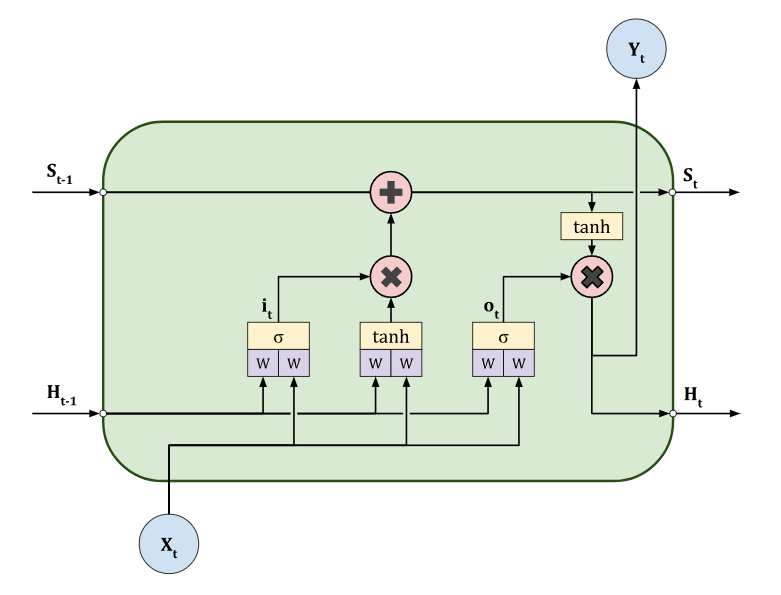

$$
\begin{align*}
g^{(t)} &= \phi\left({W^{gx}} \cdot X^{(t)} + {W^{gh}} \cdot H^{(t-1)} + b_g\right) \\
i^{(t)} &= \sigma\left({W^{ix}} \cdot X^{(t)} + {W^{ih}} \cdot H^{(t-1)} + b_i\right) \\
o^{(t)} &= \sigma\left({W^{ox}} \cdot X^{(t)} + {W^{oh}} \cdot H^{(t-1)} + b_o\right) \\
S^{(t)} &= g^{(t)} \odot i^{(t)} + S^{(t-1)} \\
H^{(t)} &= \phi\left(S^{(t)}\right) \odot o^{(t)}
\end{align*}
$$

Здесь $i^{(t)}$ и $o^{(t)}$ это соответственно, входные и выходные ворота, а $\odot$ обозначает операцию поэлементного умножения. Т.е. $i^{(t)}$ и $o^{(t)}$
 предполагаются векторами из единиц и нулей, которые пропускают или не пропускают какие-то компоненты вектора через себя.

## Code 6

In [459]:
import numpy as np
from scipy.special import expit as sigmoid
phi = np.tanh # Обычно tanh для состояния ячейки

np.random.seed(0)

# Размерности данных
x_dim = 3  # размер входного вектора
h_dim = 3  # размер скрытого состояния
g_dim = 3  # размер выходного вектора (обычно совпадает с h_dim в LSTM)

# Инициализация весов (исправлено согласно формулам)
Wgx = np.random.randn(g_dim, x_dim)  # Веса для входа gate g
Wgh = np.random.randn(g_dim, h_dim)  # Веса для скрытого состояния gate g
Wix = np.random.randn(g_dim, x_dim)  # Веса для входа gate i
Wih = np.random.randn(g_dim, h_dim)  # Веса для скрытого состояния gate i
Wox = np.random.randn(g_dim, x_dim)  # Веса для входа gate o
Woh = np.random.randn(g_dim, h_dim)  # Веса для скрытого состояния gate o

# Смещения
b_g = np.random.randn(g_dim)
b_i = np.random.randn(g_dim)
b_o = np.random.randn(g_dim)

# Инициализация состояний
H_prev = np.zeros(h_dim)  # H^(t-1)
S_prev = np.zeros(g_dim)  # S^(t-1)

def lstm_step(X_t):
    global H_prev, S_prev

    # Gate calculations
    g_t = phi(Wgx@X_t + Wgh@H_prev + b_g)
    i_t = sigmoid(Wix@X_t + Wih@H_prev + b_i)
    o_t = sigmoid(Wox@X_t + Woh@H_prev + b_o)

    # Обновление состояния ячейки
    S_t = g_t * i_t + S_prev

    # Обновление скрытого состояния
    H_t = phi(S_t) * o_t

    # Сохраняем состояния для следующего шага
    H_prev, S_prev = H_t.copy(), S_t.copy()

    return H_t, S_t

# Пример использования
X_sample = np.random.randn(x_dim)
H_new, S_new = lstm_step(X_sample)

print("Новое скрытое состояние:\n", H_new) # [-0.0465019  -0.13136722 -0.00889266]
print("Новое состояние ячейки:\n", S_new) # [-0.65243367 -0.2104553  -0.00950068]

Новое скрытое состояние:
 [-0.0465019  -0.13136722 -0.00889266]
Новое состояние ячейки:
 [-0.65243367 -0.2104553  -0.00950068]


# **7. LSTM with forget gate**

Концепция ворот так всем понравилась, что в дальнейшем добавили еще одни: forget gate, которые позволяли дополнительно занулять некоторые компоненты внутреннего состояния $S^{(t-1)}$ прежде чем передавать их дальше.

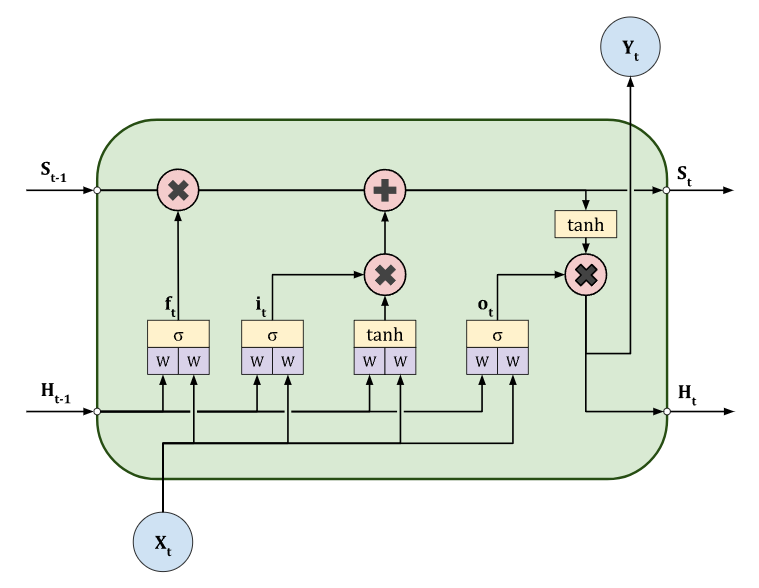

$$
\begin{align*}
g^{(t)} &= \phi\left({W^{gx}} \cdot X^{(t)} + {W^{gh}} \cdot H^{(t-1)} + b_g\right) \\
i^{(t)} &= \sigma\left({W^{ix}} \cdot X^{(t)} + {W^{ih}} \cdot H^{(t-1)} + b_i\right) \\
o^{(t)} &= \sigma\left({W^{ox}} \cdot X^{(t)} + {W^{oh}} \cdot H^{(t-1)} + b_o\right) \\
f^{(t)} &= \sigma\left({W^{fx}} \cdot X^{(t)} + {W^{fh}} \cdot H^{(t-1)} + b_f\right) \\
S^{(t)} &= g^{(t)} \odot i^{(t)} + S^{(t-1)} \odot f^{(t)} \\
H^{(t)} &= \phi\left(S^{(t)}\right) \odot o^{(t)}
\end{align*}
$$

# **8. LSTM with peephole conection**

**Peephole connection** еще одно дополнение к базовой LSTM ячейке, которое позволяет учесть текущее состояние $S^{(t-1)}$ в вычислении всевозможных ворот:

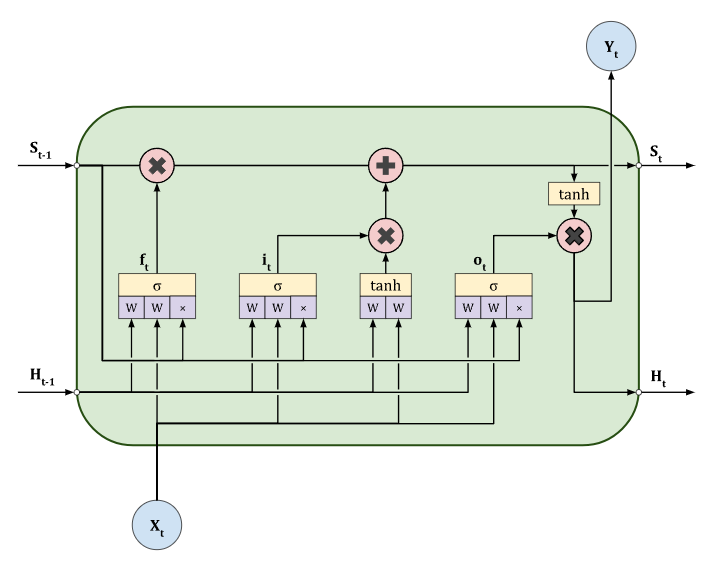

$$
\begin{align*}
g^{(t)} &= \phi\left({W^{gx}} \cdot X^{(t)} + {W^{gh}} \cdot H^{(t-1)} + b_g\right) \\
i^{(t)} &= \sigma\left({W^{ix}} \cdot X^{(t)} + {W^{ih}} \cdot H^{(t-1)} + P_i \odot S^{(t-1)} + b_i\right) \\
o^{(t)} &= \sigma\left({W^{ox}} \cdot X^{(t)} + {W^{oh}} \cdot H^{(t-1)} + P_o \odot S^{(t-1)} + b_o\right) \\
f^{(t)} &= \sigma\left({W^{fx}} \cdot X^{(t)} + {W^{fh}} \cdot H^{(t-1)} + P_f \odot S^{(t-1)} + b_f\right) \\
S^{(t)} &= g^{(t)} \odot i^{(t)} + S^{(t-1)} \odot f^{(t)} \\
H^{(t)} &= \phi\left(S^{(t)}\right) \odot o^{(t)}
\end{align*}
$$

Т.е. мы дополнительно тренируем три набора весов $P_i, P_o, P_f$, которые фильтруют текущее состояние, для использования в соответствующих воротах. Заметим, что **peephole connection** можно использовать и в ячейках без **forget gate**, просто здесь расписаны формулы максимально общего LSTM.

# ⚡ **GRU**

# **9. Gated Recurrent Unit**

Еще один вариант ячейки, очень похожий на LSTM, но с меньшим количеством “ворот” (двумя), а значит и параметров (качество при этом обещают сравнимое с LSTM с таким же количеством параметров):

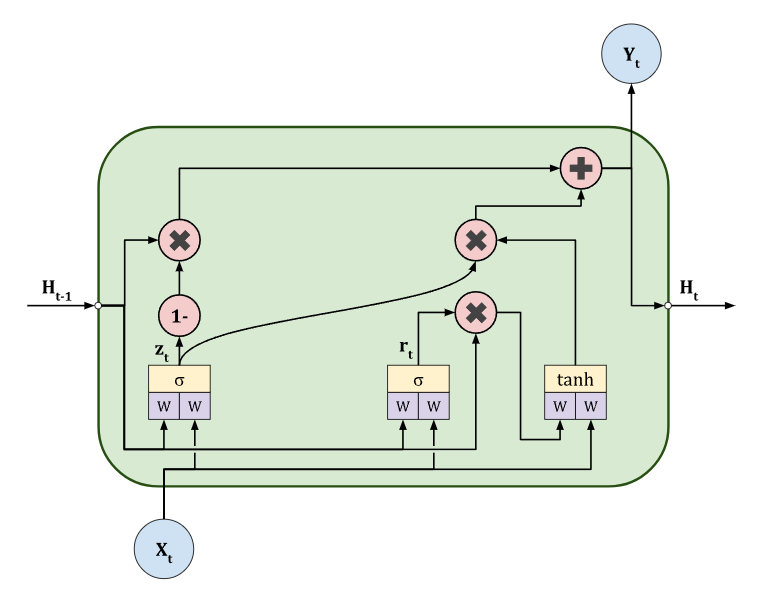

$$
\begin{align*}
z^{(t)} &= \sigma\left( W^{zx} \cdot X^{(t)} + W^{zh} \cdot H^{(t-1)} + b_z \right) \\
r^{(t)} &= \sigma\left( W^{rx} \cdot X^{(t)} + W^{rh} \cdot H^{(t-1)} + b_r \right) \\
\bar{H}^{(t)} &= \phi\left( W^{\tilde{h}x} \cdot X^{(t)} + W^{\tilde{h}h} \cdot \left( r^{(t)} \odot H^{(t-1)} \right) + b_{\tilde{h}} \right) \\
H^{(t)} &= \left(1 - z^{(t)}\right) \odot H^{(t-1)} + z^{(t)} \odot \bar{H}^{(t)}
\end{align*}
$$

## Разбор архитектуры GRU
Архитектура GRU (Gated Recurrent Unit) разработана для эффективного управления потоком информации в рекуррентных нейронных сетях (RNN), позволяя модели сохранять долгосрочные зависимости и избегать проблем исчезающих или взрывающихся градиентов. Её структура основана на двух ключевых механизмах — **гейте обновления** $z^{(t)}$ и **гейте сброса** $r^{(t)}$ — которые работают согласованно для адаптивного обновления скрытого состояния. Вот подробное объяснение:

---

### 1. **Гейт обновления $z^{(t)}$**
   - **Функция**: Определяет, какая часть предыдущего скрытого состояния $H^{(t-1)}$ сохраняется, а какая заменяется новым промежуточным состоянием $\bar{H}^{(t)}$.
   - **Формула**:
     $$
     z^{(t)} = \sigma\left(W^{zx} \cdot X^{(t)} + W^{zh} \cdot H^{(t-1)} + b_z\right)
     $$
   - **Логика**:
     - Если $z^{(t)} \approx 1$, новое состояние $H^{(t)}$ в основном определяется промежуточным состоянием $\bar{H}^{(t)}$ (обновление).
     - Если $z^{(t)} \approx 0$, сохраняется предыдущее состояние $H^{(t-1)}$ (забывание).

---

### 2. **Гейт сброса $r^{(t)}$**
   - **Функция**: Контролирует, какая часть предыдущего состояния $H^{(t-1)}$ влияет на вычисление промежуточного состояния $\bar{H}^{(t)}$.
   - **Формула**:
     $$
     r^{(t)} = \sigma\left(W^{rx} \cdot X^{(t)} + W^{rh} \cdot H^{(t-1)} + b_r\right)
     $$
   - **Логика**:
     - Если $r^{(t)} \approx 0$, предыдущее состояние игнорируется при вычислении $\bar{H}^{(t)}$ (сброс).
     - Если $r^{(t)} \approx 1$, предыдущее состояние полностью учитывается.

---

### 3. **Промежуточное состояние $\bar{H}^{(t)}$**
   - **Функция**: Вычисляет "кандидата" для нового скрытого состояния, комбинируя текущий вход $X^{(t)}$ и частично сохранённое предыдущее состояние (взвешенное гейтом сброса).
   - **Формула**:
     $$
     \bar{H}^{(t)} = \phi\left(W^{\tilde{h}x} \cdot X^{(t)} + W^{\tilde{h}h} \cdot \left(r^{(t)} \odot H^{(t-1)}\right) + b_{\tilde{h}}\right)
     $$
   - **Логика**:
     - Гейт сброса $r^{(t)}$ регулирует вклад $H^{(t-1)}$ в промежуточное состояние. Например, если $r^{(t)} = 0$, сеть "забывает" прошлое и фокусируется только на текущем входе $X^{(t)}$.

---

### 4. **Финальное скрытое состояние $H^{(t)}$**
   - **Формула**:
     $$
     H^{(t)} = \left(1 - z^{(t)}\right) \odot H^{(t-1)} + z^{(t)} \odot \bar{H}^{(t)}
     $$
   - **Логика**:
     - Гейт обновления $z^{(t)}$ балансирует между сохранением старого состояния $H^{(t-1)}$ и включением нового $\bar{H}^{(t)}$.
     - Это позволяет модели гибко адаптироваться: сохранять информацию на долгих временных интервалах или быстро обновлять её при поступлении важных данных.

---

### **Почему именно такая архитектура?**
1. **Упрощение по сравнению с LSTM**:
   - В LSTM используются три гейта (входной, забывания, выходной) и отдельная ячейка памяти. GRU объединяет гейты забывания и входа в **гейт обновления**, а также исключает ячейку памяти, используя прямое обновление скрытого состояния. Это уменьшает количество параметров и вычислительную сложность.

2. **Баланс между гибкостью и эффективностью**:
   - Два гейта $z^{(t)}$ и $r^{(t)}$ обеспечивают достаточный контроль над информационным потоком, сохраняя способность работать с долгосрочными зависимостями.
   - Отсутствие отдельной ячейки памяти упрощает обучение, но сохраняет ключевые преимущества управления состоянием.

3. **Активационные функции**:
   - Сигмоида $\sigma$ для гейтов: возвращает значения в диапазоне $[0, 1]$, что удобно для управления весами.
   - Гиперболический тангенс $\phi$ для промежуточного состояния: обеспечивает выходы в диапазоне $[-1, 1]$, что помогает стабилизировать градиенты.

---

### **Преимущества GRU**
- **Меньше параметров**: По сравнению с LSTM, GRU требует меньше вычислительных ресурсов и памяти.
- **Эффективность на коротких последовательностях**: Часто показывает сопоставимую с LSTM производительность при меньшей сложности.
- **Устойчивость к исчезающим градиентам**: Механизм гейтов позволяет передавать информацию через многие временные шаги.

---

### **Недостатки**
- **Меньшая гибкость**: Объединение гейтов может ограничивать способность модели к тонкой настройке информационного потока по сравнению с LSTM.
- **Сложность на очень длинных последовательностях**: В некоторых задачах LSTM всё же превосходит GRU благодаря отдельной ячейке памяти.

---

### **Заключение**
GRU — это компромисс между простотой традиционных RNN и мощью LSTM. Его архитектура оптимизирована для эффективного обучения на последовательностях с сохранением ключевых механизмов управления информацией, что делает его популярным выбором в задачах обработки естественного языка, прогнозирования временных рядов и других приложений, требующих работы с последовательными данными.

In [460]:
import numpy as np
from scipy.special import expit as sigmoid
phi = np.tanh  # Обычно tanh для скрытого состояния

np.random.seed(0)

# Размерности данных
x_dim = 3  # Размер входного вектора
h_dim = 3  # Размер скрытого состояния

# Инициализация весов
Wzx = np.random.randn(h_dim, x_dim)  # Веса для update gate (z)
Wzh = np.random.randn(h_dim, h_dim)
bz = np.random.randn(h_dim)

Wrx = np.random.randn(h_dim, x_dim)  # Веса для reset gate (r)
Wrh = np.random.randn(h_dim, h_dim)
br = np.random.randn(h_dim)

Wtildehx = np.random.randn(h_dim, x_dim)  # Веса для candidate activation
Wtildehh = np.random.randn(h_dim, h_dim)
btildeh = np.random.randn(h_dim)

# Инициализация скрытого состояния
H_prev = np.zeros(h_dim)

def gru_step(X_t):
    global H_prev

    # Вычисление гейтов
    z_t = sigmoid(Wzx @ X_t + Wzh @ H_prev + bz)
    r_t = sigmoid(Wrx @ X_t + Wrh @ H_prev + br)

    # Кандидатское обновление скрытого состояния
    h_tilde = phi(Wtildehx @ X_t + Wtildehh @ (r_t * H_prev) + btildeh)

    # Обновление скрытого состояния
    H_t = (1 - z_t) * H_prev + z_t * h_tilde

    # Сохраняем состояние для следующего шага
    H_prev = H_t.copy()

    return H_t

# Пример использования
X_sample = np.random.randn(x_dim)
H_new = gru_step(X_sample)

print("Новое скрытое состояние GRU:\n", H_new)  # Пример вывода

Новое скрытое состояние GRU:
 [ 0.04471049 -0.0024696   0.01478697]


**Пояснения:**

1. **Инициализация параметров:**
   - Веса `Wzx`, `Wrx`, `Wtildehx` отвечают за преобразование входного вектора `X_t`.
   - Веса `Wzh`, `Wrh`, `Wtildehh` работают с предыдущим скрытым состоянием `H_prev`.
   - Смещения `bz`, `br`, `btildeh` добавляются после линейных преобразований.

2. **Функция `gru_step`:**
   - **Update gate (`z_t`):** Определяет, какая часть предыдущего состояния сохранится.
   - **Reset gate (`r_t`):** Управляет влиянием предыдущего состояния на кандидата `h_tilde`.
   - **Кандидат `h_tilde`:** Рассчитывается с учетом "сброса" истории через `r_t`.
   - **Итоговое состояние `H_t`:** Интерполяция между старым состоянием и кандидатом через `z_t`.


# **10. Minimal Gated Unit**

Наконец, был предложен вариант ячейки, с минимальным числом параметров при это качеством не уступающий GRU. Он содержит только одни “ворота”, а именно **forget gate**:

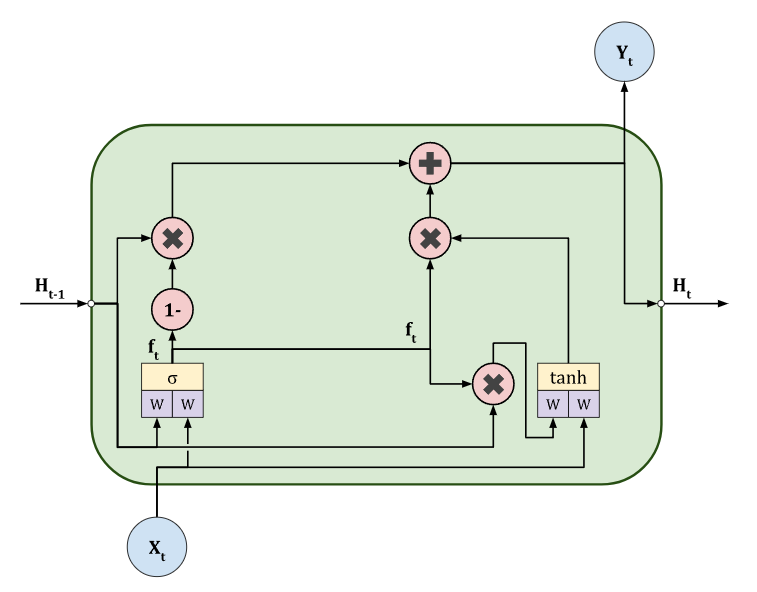

$$
\begin{align*}
f^{(t)} &= \sigma\left( W^{fx} \cdot X^{(t)} + W^{fh} \cdot H^{(t-1)} + b_f \right) \\
\bar{H}^{(t)} &= \phi\left( W^{\tilde{h}x} \cdot X^{(t)} + W^{\tilde{h}h} \cdot \left( f^{(t)} \odot H^{(t-1)} \right) + b_{\tilde{h}} \right) \\
H^{(t)} &= \left(1 - f^{(t)}\right) \odot H^{(t-1)} + f^{(t)} \odot \bar{H}^{(t)}
\end{align*}
$$

## Code 7

In [461]:
# Code #7
# Реализуйте Minimal Gated Unit

np.random.seed(0)

# Размерности данных
x_dim = 3  # Размер входного вектора
h_dim = 3  # Размер скрытого состояния

# Инициализация весов
Wfx = np.random.randn(h_dim, x_dim)  # Веса для update gate (z)
Wfh = np.random.randn(h_dim, h_dim)
b_f = np.random.randn(h_dim)

Wtildehx = np.random.randn(h_dim, x_dim)  # Веса для candidate activation
Wtildehh = np.random.randn(h_dim, h_dim)
btildeh = np.random.randn(h_dim)

phi = np.tanh

def MGUcell(x_t, h_prev):

    f_t = sigmoid(Wfx@x_t + Wfh@h_prev+b_f)
    H_tilde = phi(Wtildehx@x_t + Wtildehh@(f_t*h_prev) + btildeh)
    H_t = (1 - f_t)*h_prev + f_t*H_tilde

    return H_t

# Пример использования
H_prev = np.zeros(h_dim)
X_sample = np.random.randn(x_dim)
H_new = MGUcell(X_sample, H_prev)

print("Новое скрытое состояние GRU:\n", H_new)  # Пример вывода
# Новое скрытое состояние GRU:
# [-0.38979287  0.09833883 -0.56350752]

Новое скрытое состояние GRU:
 [ 0.04672885 -0.36902367  0.00971787]


# **11. Bidirectional recurrent neural network**

Еще один вариант рекуррентной архитектуры. Здесь предполагается, что входная последовательность известна сразу и вся, и данные подаются как бы сразу и с начала последовательности и с конца. Т.е. мы, в отличии от обычной рекуррентной ячейки, не можем заталкивать туда бесконечную последовательность и снимать отклик в каждый момент времени (но это зачастую и не нужно). Зато такой вариант позволяет учесть не только связи от начальных элементов к конечным, но и наоборот. Даже если мы просто хотим определить части речи в предложении это иногда бывает полезно.

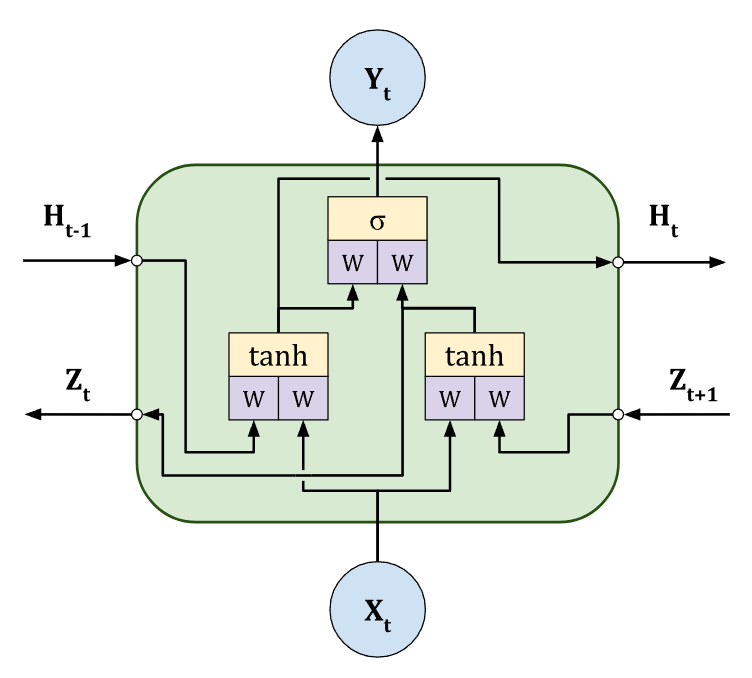

$$
\begin{align*}
H^{(t)} &= \phi \left( W^{hx} \cdot X^{(t)} + W^{hh} \cdot H^{(t-1)} + b_h \right) \\
Z^{(t)} &= \phi \left( W^{zx} \cdot X^{(t)} + W^{zz} \cdot Z^{(t+1)} + b_z \right) \\
Y^{(t)} &= \sigma \left( W^{yh} \cdot H^{(t)} + W^{yz} \cdot Z^{(t)} + b_y \right)
\end{align*}
$$

**Пояснения:**
1. **Формула для $ H^{(t)} $**:
   - Описывает обновление скрытого состояния в момент времени $ t $ на основе текущего входа $ X^{(t)} $ и предыдущего состояния $ H^{(t-1)} $.
   - $ \phi $ — функция активации (например, гиперболический тангенс).

2. **Формула для $ Z^{(t)} $**:
   - Определяет состояние $ Z^{(t)} $, зависящее от текущего входа $ X^{(t)} $ и **последующего** состояния $ Z^{(t+1)} $.
   - Такая структура характерна для двунаправленных RNN, где информация передаётся как вперёд, так и назад.

3. **Формула для $ Y^{(t)} $**:
   - Вычисляет выход сети $ Y^{(t)} $ на основе текущего скрытого состояния $ H^{(t)} $ и состояния $ Z^{(t)} $.
   - $ \sigma $ — сигмоидальная функция активации (например, для задачи классификации).

# 🔥 **Автокодировщик (Autoencoder)**

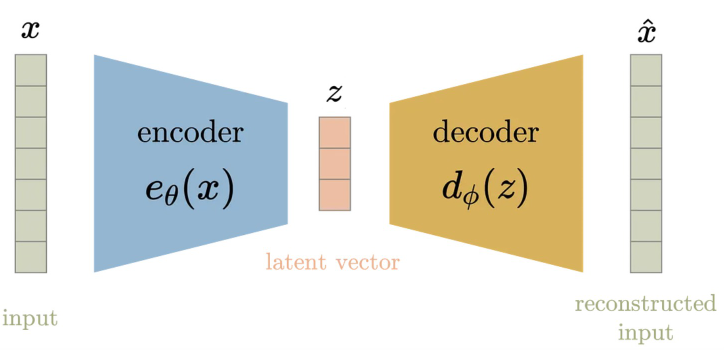

## Code 8

Напишите свой Autoencoder:

1.   Нейронка учится на X_train и сверяется с X_train. Латентное пространство размером 2.
```
nn = NeuralNetwork(X_train.shape[1], 2, X_train.shape[1], 0.05, relu, 150)
nn.fit(X_train, X_train)
nn.score(X_test, X_test)
```
2.   Поменяйте методы predict и score. score пусть считает MAE или MSE.

In [462]:
import numpy as np
from scipy.special import expit as relu
from dataclasses import dataclass
norm = np.random.normal

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder

iris = load_iris()
X, y = iris['data'], iris['target']
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(X)
y = OneHotEncoder().fit_transform(y.reshape(-1, 1)).toarray()
y = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

@dataclass
class NeuralNetwork:
  inp: ... # input  nodes
  hid: ... # hidden nodes
  out: ... # output nodes
  lr:  ... # learning rate
  act: ... # activation function
  epo: ... # epochs

  def __post_init__(s): # generate weights
    s.wih = norm(0., np.sqrt(s.inp), (s.hid, s.inp))
    s.who = norm(0., np.sqrt(s.hid), (s.out, s.hid))

  def train(s, x, y):
    x = np.array(x, ndmin=2).T
    y = np.array(y, ndmin=2).T

    ho = s.act(s.wih @ x)  # hidden outputs
    fo = s.act(s.who @ ho) # final  outputs
    oe = y - fo            # output errors
    he = s.who.T @ oe      # hidden errors
    s.who += s.lr * (oe * fo * (1. - fo)) @ ho.T
    s.wih += s.lr * (he * ho * (1. - ho)) @ x.T
    return (oe**2).mean()

  def query(s, x):
    x = np.array(x, ndmin=2).T
    return s.act(s.who @ s.act(s.wih @ x))
  
  def query_latent(s, x):
    x = np.array(x, ndmin=2).T
    return s.act(s.wih @ x)

  def fit(s, X, y):
    log = []
    for e in range(s.epo):
      #print(f"epoch: {e}")
      l = 0
      for i in range(len(y)):
        l += s.train(X[i], y[i])
      log.append(l)
    return log

  def predict(s, X):
    #return np.array([np.argmax(s.query(x)) for x in X])
    return s.query(X)

  def score(s, X, y):
    #y = np.array([np.argmax(i) for i in y])
    #return (s.predict(X) == y).mean()
    return ((s.predict(X).T - y)**2).mean()

nn = NeuralNetwork(X.shape[1], 10, y.shape[1], 0.1, relu, 50)
nn.fit(X_train, y_train)
nn.score(X_test, y_test)

0.0672084684334111

In [463]:
nn.predict(X_test[0]).shape, y_train.shape

((3, 1), (112, 3))

## Code 9

1.   Обучите на MNIST, не забыв про MinMaxScaler.
2.   После fit проверьте, что нейронка вернула картинку похожую на исходную.

```
im_true = X_test[0].reshape(8, 8)
plt.imshow(im_true, cmap='gray')
```

```
nn = NeuralNetwork(X_train.shape[1], 2, X_train.shape[1], 0.05, relu, 150)
nn.fit(X_train, X_train)
im_pred = nn.query(X_test[0]).reshape(8, 8)
plt.imshow(im_pred, cmap='gray')
```

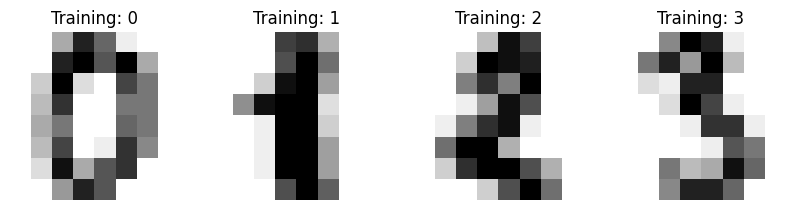

In [464]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
digits = datasets.load_digits()

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for ax, image, label in zip(axes, digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % label)

In [465]:
digits.images[0], digits.target[0]

(array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
        [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
        [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
        [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
        [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
        [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
        [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
        [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]]),
 0)

In [466]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
data[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

In [467]:
image = data[0].reshape(8, 8)
image

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

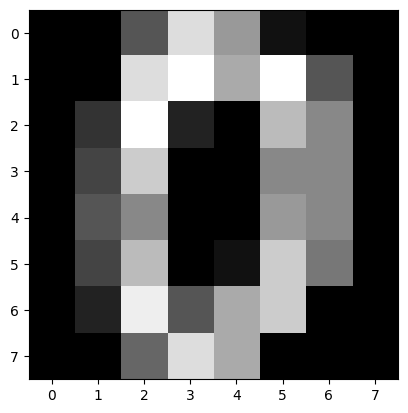

In [468]:
plt.imshow(image, cmap='gray')

In [469]:
X = MinMaxScaler(feature_range=(0.01, 0.99)).fit_transform(data)
X[0]

array([0.01      , 0.01      , 0.31625   , 0.80625   , 0.56125   ,
       0.07125   , 0.01      , 0.01      , 0.01      , 0.01      ,
       0.80625   , 0.92875   , 0.6225    , 0.92875   , 0.31625   ,
       0.01      , 0.01      , 0.19375   , 0.92875   , 0.1325    ,
       0.01      , 0.68375   , 0.5       , 0.01      , 0.01      ,
       0.27133333, 0.745     , 0.01      , 0.01      , 0.5       ,
       0.53266667, 0.01      , 0.01      , 0.36      , 0.5       ,
       0.01      , 0.01      , 0.56125   , 0.57      , 0.01      ,
       0.01      , 0.255     , 0.68375   , 0.01      , 0.07125   ,
       0.745     , 0.43875   , 0.01      , 0.01      , 0.1325    ,
       0.8675    , 0.31625   , 0.6225    , 0.745     , 0.01      ,
       0.01      , 0.01      , 0.01      , 0.3775    , 0.80625   ,
       0.6225    , 0.01      , 0.01      , 0.01      ])

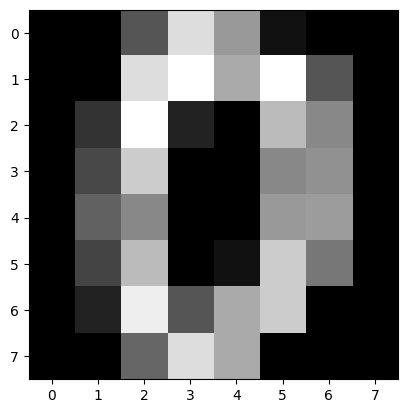

In [470]:
plt.imshow(X[0].reshape(8, 8), cmap='gray')

In [471]:
X_train, X_test, y_train, y_test = train_test_split(X, digits.target, test_size=0.2, random_state=42, shuffle=True)
y_train = y_train.reshape((1437, 1))
y_test = y_test.reshape((360, 1))

In [472]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1437, 64), (360, 64), (1437, 1), (360, 1))

In [473]:
ae = NeuralNetwork(X_train.shape[1], 2, X_train.shape[1], 0.05, relu, 1100)
loss = ae.fit(X_train, X_train)
ae.score(X_test, X_test)

0.06118863547844336

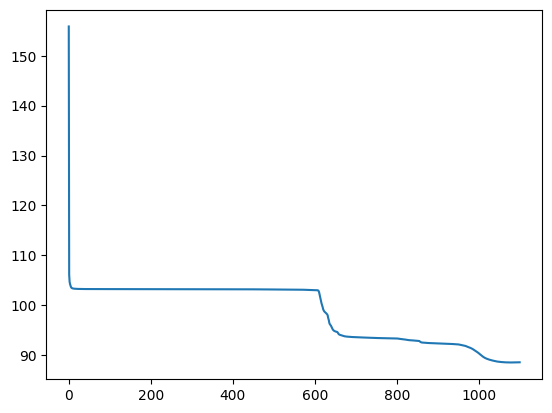

In [474]:
plt.plot(np.arange(len(loss)), loss)

[4]


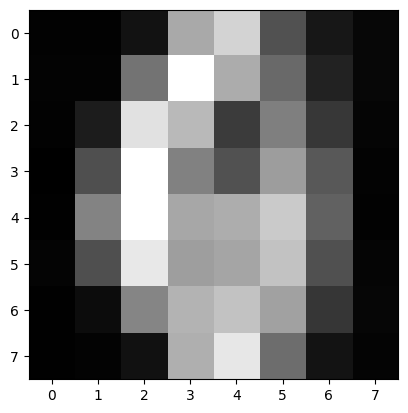

In [475]:
i = 100
plt.imshow(ae.predict(X_test[i]).reshape((8, 8)), cmap="grey")
print(y_test[i])

## Code 10

1.   Напишите метод query_latent, который вернёт латентное пространство
2.   Постройте scatter с нулями и потом с единицами

```
num_0 = digits_latent[digits.target==0]
plt.scatter(num_0[:, 0], num_0[:, 1])
```

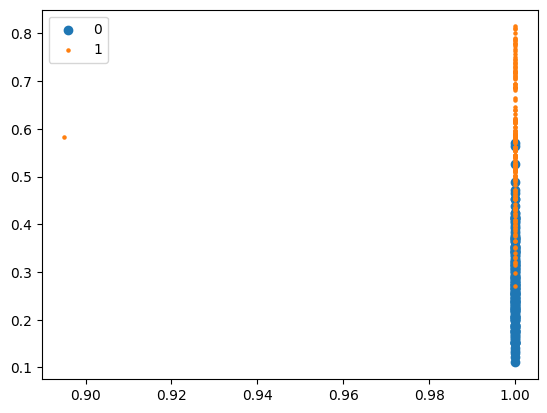

In [491]:
# code #10
num0 = X[digits.target==0]
num1 = X[digits.target==1]
latent0 = ae.query_latent(num0).T
latent1 = ae.query_latent(num1).T
plt.scatter(latent0[:, 0], latent0[:, 1], label="0")
plt.scatter(latent1[:, 0], latent1[:, 1], label="1", s=5)
plt.legend()